# Crosstalk matrix — NV-array multiplexing

Builds the 3x3 (drive frequency) x (readout row) crosstalk matrix from the
three already-collected `SPAD_time_rabi_npzprocess_batch`-style datasets
(rows 486/493/503), and checks whether the signal-to-noise ratio on the
off-diagonal (crosstalk) cells is high enough to trust a fitted amplitude, or
whether more averaging is needed first.

See `experimental_plan.md` in this directory for the full context and
rationale (item 1 and the fitting-methodology note).

**Matrix layout:** each dataset drives one physical row on resonance. Its own
3x3 pixel grid (same ±2-pixel sparse spacing used in
`SPAD_time_rabi_npzprocess_batch.ipynb`, matching the NV array pitch) also
captures the two other physical rows off-resonance, so **no new data
acquisition is needed** — this notebook only reprocesses the existing three
datasets.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'experiment-main').exists():
            return p
    raise RuntimeError('Could not find workspace root containing experiment-main')

WORKSPACE = find_workspace_root(Path.cwd())
spad_dir = WORKSPACE / 'SPAD data'
processed_dir = spad_dir / 'processed'

## 1. Datasets

Same three drive-frequency datasets described in `experimental_plan.md`:
bottom row (486), middle row (493), top row (503), each a single fixed low
drive power (Ω≈0.5 MHz) with 7–10 tracking iterations.

In [2]:
DATASETS = {
    'bottom_486': {
        'time_rabi_tracking_20260715-184625-591686_iter001__486_time_rabi_gradient_tracking_191405_avg.npz',
        'time_rabi_tracking_20260715-191807-926601_iter002__486_time_rabi_gradient_tracking_191405_avg.npz',
        'time_rabi_tracking_20260715-194949-591523_iter003__486_time_rabi_gradient_tracking_191405_avg.npz',
        'time_rabi_tracking_20260715-202131-119836_iter004__486_time_rabi_gradient_tracking_191405_avg.npz',
        'time_rabi_tracking_20260715-205314-126500_iter005__486_time_rabi_gradient_tracking_191405_avg.npz',
        'time_rabi_tracking_20260715-212455-585853_iter006__486_time_rabi_gradient_tracking_191405_avg.npz',
        'time_rabi_tracking_20260715-215637-527180_iter007__486_time_rabi_gradient_tracking_191405_avg.npz',
    },
    'middle_493': {
        'time_rabi_tracking_20260715-223619-254812_iter001__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260715-230800-770669_iter002__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260715-233942-277822_iter003__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260716-001123-914207_iter004__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260716-004305-461278_iter005__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260716-011447-141334_iter006__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260716-014628-868784_iter007__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260716-021810-561034_iter008__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260716-024952-434213_iter009__493_time_rabi_gradient_tracking_230359_avg.npz',
        'time_rabi_tracking_20260716-032134-006057_iter010__493_time_rabi_gradient_tracking_230359_avg.npz',
    },
    'top_503': {
        'time_rabi_tracking_20260716-082443-894774_iter001__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-085625-764846_iter002__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-092809-551421_iter003__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-095951-480153_iter004__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-103132-974934_iter005__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-110314-609963_iter006__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-113456-174293_iter007__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-120637-768574_iter008__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-123819-484512_iter009__503_time_rabi_gradient_tracking_085223_avg.npz',
        'time_rabi_tracking_20260716-131001-519783_iter010__503_time_rabi_gradient_tracking_085223_avg.npz',
    },
}

DELTA_NOMINAL_MHZ = 1.4   # nearest-neighbor row-to-row gradient splitting
SNR_THRESHOLD = 3.0       # amplitude / uncertainty threshold for a trustworthy fit

## 2. Loading and the per-row, per-dataset contrast trace

For each dataset we reuse the same per-file `bright_rc` + ±2-pixel 3x3 grid
indexing as `SPAD_time_rabi_npzprocess_batch.ipynb`. The three *columns* of
the grid sample different emitters that share the same nominal drive
frequency (the gradient is 1-D, along rows only), so we combine them by
averaging — free extra statistics from data already collected, no new
acquisition. Each dataset then yields exactly 3 row traces: 1 addressed
(on-resonance) + 2 off-resonance (crosstalk) rows.

In [3]:
def load_dataset(file_set):
    sig_all, ref_all, reps_all = [], [], []
    t_vec = None
    for fname in sorted(file_set):  # sorted: deterministic regardless of set hash order
        path = processed_dir / fname
        with np.load(path, allow_pickle=True) as npz:
            sig_all.append(np.asarray(npz['sig_avg_cps_bgsub']))
            ref_all.append(np.asarray(npz['ref_avg_cps_bgsub']))
            t_vec = 4 * np.asarray(npz['t_vec'])
            reps_all.append(int(np.asarray(npz['n_complete_reps']).item()))
    return {'sig': np.array(sig_all), 'ref': np.array(ref_all),
            'reps': reps_all, 't_vec': t_vec}


def combined_row_traces(data):
    # Returns (3, N) array: weighted-avg over files, then averaged over the
    # 3 columns of the 3x3 grid.
    sig, ref, reps, t_vec = data['sig'], data['ref'], data['reps'], data['t_vec']
    n_files = sig.shape[0]
    row_traces = []
    for i in range(3):
        col_traces = []
        for j in range(3):
            per_file = []
            for k in range(n_files):
                ref_frame = ref[k].mean(axis=0)
                bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
                r = bright_rc[0] + 2 * i - 2
                c = bright_rc[1] + 2 * j - 2
                sig_pix = sig[k, :, r, c]
                ref_pix = ref[k, :, r, c]
                per_file.append(1 - (ref_pix - sig_pix) / ref_pix)
            per_file = np.array(per_file)
            col_traces.append(np.average(per_file, axis=0, weights=reps))
        row_traces.append(np.mean(col_traces, axis=0))
    return np.array(row_traces), t_vec


loaded, row_traces_by_ds = {}, {}
for label, files in DATASETS.items():
    print(f'Loading {label} ({len(files)} files)...')
    data = load_dataset(files)
    loaded[label] = data
    row_traces_by_ds[label], t_vec = combined_row_traces(data)
print('Done loading.')

Loading bottom_486 (7 files)...
Loading middle_493 (10 files)...
Loading top_503 (10 files)...
Done loading.


## 3. Identify the addressed row and fit it

The addressed (on-resonance) row is identified per dataset as whichever of
the 3 rows has the largest variance of the mean-subtracted trace — the
on-resonance Rabi oscillation is much bigger than off-resonant crosstalk or
noise.

The frequency guess fed to `curve_fit` matters: the naive
`1/(2*(t[-1]-t[0]))` heuristic used in the original notebook can be many x
off from the true ~0.5 MHz for a short/fast-decaying trace, and the fit can
lock onto a spurious local optimum as a result (this was caught empirically —
see the note after the fit results below). Seeding from the FFT peak instead
is far more robust.

In [4]:
def damped_cosine(t, amp, freq, phase, decay, offset):
    return offset + amp * np.cos(2 * np.pi * freq * t + phase) * np.exp(-t / decay)


def fft_freq_guess(t, y):
    dt = t[1] - t[0]
    spec = np.abs(np.fft.rfft(y - y.mean()))
    freqs = np.fft.rfftfreq(len(t), d=dt)
    peak = np.argmax(spec[1:]) + 1  # skip DC bin
    return freqs[peak]


def fit_free(t, y):
    dt = t[1] - t[0]
    freq_guess = fft_freq_guess(t, y)
    p0 = [(y.max() - y.min()) / 2, freq_guess, 0.0, t[-1] / 2, y.mean()]
    bounds = ([-1.0, 0.0, -np.pi, dt, 0.9], [1.0, 1.0, np.pi, 1e6, 1.1])
    popt, pcov = curve_fit(damped_cosine, t, y, p0=p0, bounds=bounds, maxfev=20000)
    return popt, pcov


addressed_by_ds, omega_fit_by_ds = {}, {}
for label, row_traces in row_traces_by_ds.items():
    variances = [np.var(y - y.mean()) for y in row_traces]
    addressed_i = int(np.argmax(variances))
    addressed_by_ds[label] = addressed_i
    popt, pcov = fit_free(loaded[label]['t_vec'], row_traces[addressed_i])
    omega_fit_by_ds[label] = popt[1] * 1000  # MHz
    print(f'{label}: addressed row index={addressed_i}  row variances={[f"{v:.2e}" for v in variances]}')
    print(f'    own free-fit: Omega={popt[1]*1000:.4f} MHz  decay={popt[3]:.0f} ns  amp={popt[0]:.5f}')

bottom_486: addressed row index=2  row variances=['9.70e-07', '1.19e-06', '1.24e-05']
    own free-fit: Omega=0.1355 MHz  decay=17608 ns  amp=0.00788
middle_493: addressed row index=1  row variances=['1.82e-06', '6.03e-06', '1.73e-06']
    own free-fit: Omega=0.5403 MHz  decay=3440 ns  amp=0.00593
top_503: addressed row index=0  row variances=['1.02e-05', '1.51e-06', '2.26e-06']
    own free-fit: Omega=0.5342 MHz  decay=4411 ns  amp=0.00721


## 4. Cross-calibrate a shared Ω

All three datasets target the same nominal drive power (Ω≈0.5 MHz), so
rather than trusting each dataset's own addressed-row fit individually for
its Ω_eff calculation, take the **median** across the three as a shared,
more robust Ω. Median (not mean) specifically because a single dataset's fit
landing in a bad local optimum (frequency/decay degeneracy — very plausible
when the trace barely resolves one oscillation cycle before decaying) would
otherwise bias a mean but is automatically down-weighted by a median.

In [5]:
omega_values = list(omega_fit_by_ds.values())
omega_shared_mhz = float(np.median(omega_values))
print(f'Per-dataset addressed-row Omega (MHz): {omega_fit_by_ds}')
print(f'Shared (median) Omega used for all Omega_eff calculations: {omega_shared_mhz:.4f} MHz')
for label, om in omega_fit_by_ds.items():
    if abs(om - omega_shared_mhz) > 0.05:
        print(f'  NOTE: {label} own fit ({om:.3f} MHz) deviates substantially from the shared '
              f'Omega -- treat as a poorly-constrained fit (short/fast-decaying trace), not a '
              f'real difference in drive power. Its own Omega_eff calculation below uses the '
              f'shared Omega instead.')

Per-dataset addressed-row Omega (MHz): {'bottom_486': 0.1354729693878816, 'middle_493': 0.5403287137080619, 'top_503': 0.5342129795326173}
Shared (median) Omega used for all Omega_eff calculations: 0.5342 MHz
  NOTE: bottom_486 own fit (0.135 MHz) deviates substantially from the shared Omega -- treat as a poorly-constrained fit (short/fast-decaying trace), not a real difference in drive power. Its own Omega_eff calculation below uses the shared Omega instead.


## 5. Fixed-frequency (matched-filter) fit for the crosstalk cells

For each non-addressed row, fix the frequency at the model-predicted
`Ω_eff = sqrt(Ω_shared² + δ²)` (δ = 1.4 MHz x row-hops — 1 hop = nearest
neighbor, 2 hops = next-nearest) and fit only amplitude + phase by *linear*
least squares. This is a matched-filter / lock-in-style estimator: much more
robust than a free 5-parameter nonlinear fit when the signal is only
marginally above the noise floor, and it gives a trustworthy covariance-based
uncertainty on the amplitude.

In [6]:
def fit_fixed_freq(t, y, freq_cycles_per_ns):
    w = 2 * np.pi * freq_cycles_per_ns
    A = np.column_stack([np.ones_like(t), np.cos(w * t), np.sin(w * t)])
    coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
    resid = y - A @ coeffs
    dof = len(t) - 3
    sigma2 = np.sum(resid**2) / dof
    cov = sigma2 * np.linalg.inv(A.T @ A)
    offset, a, b = coeffs
    amp = np.hypot(a, b)
    da2, db2, cov_ab = cov[1, 1], cov[2, 2], cov[1, 2]
    amp_unc = np.sqrt((a / amp) ** 2 * da2 + (b / amp) ** 2 * db2
                       + 2 * (a / amp) * (b / amp) * cov_ab)
    return amp, amp_unc, offset


summary_rows = []
for label in DATASETS:
    row_traces = row_traces_by_ds[label]
    addressed_i = addressed_by_ds[label]
    t_vec = loaded[label]['t_vec']
    n_current = len(loaded[label]['reps']) * 3  # files x columns already combined

    y_addr = row_traces[addressed_i]
    popt, pcov = fit_free(t_vec, y_addr)
    addr_amp, addr_amp_unc = popt[0], np.sqrt(pcov[0, 0])
    summary_rows.append(dict(dataset=label, cell='addressed', row_index=addressed_i,
                              row_hops=0, delta_mhz=0.0, kind='on-resonance',
                              amp=addr_amp, amp_unc=addr_amp_unc,
                              snr=addr_amp / addr_amp_unc, n_current=n_current, n_needed=n_current))

    for i in range(3):
        if i == addressed_i:
            continue
        row_hops = abs(i - addressed_i)
        delta_mhz = DELTA_NOMINAL_MHZ * row_hops
        kind = 'nearest' if row_hops == 1 else 'next-nearest'
        omega_eff_mhz = np.sqrt(omega_shared_mhz ** 2 + delta_mhz ** 2)
        amp, amp_unc, _ = fit_fixed_freq(t_vec, row_traces[i], omega_eff_mhz * 1e-3)
        snr = amp / amp_unc if amp_unc > 0 else np.nan
        n_needed = n_current * (SNR_THRESHOLD / snr) ** 2 if snr > 0 else np.inf
        summary_rows.append(dict(dataset=label, cell=f'row{i}', row_index=i, row_hops=row_hops,
                                  delta_mhz=delta_mhz, kind=kind, amp=amp, amp_unc=amp_unc, snr=snr,
                                  n_current=n_current, n_needed=n_needed))

header = '{:<12}{:<10}{:<14}{:>11}{:>10}{:>10}{:>7}{:>24}'.format(
    'dataset', 'cell', 'kind', 'delta(MHz)', 'amp', 'amp_unc', 'SNR', 'verdict')
print(header)
for r in summary_rows:
    if r['snr'] >= SNR_THRESHOLD:
        verdict = 'OK'
    else:
        verdict = 'NEED ~{:.1f}x MORE AVG'.format(r['n_needed'] / r['n_current'])
    line = '{:<12}{:<10}{:<14}{:>11.1f}{:>10.5f}{:>10.5f}{:>7.2f}{:>24}'.format(
        r['dataset'], r['cell'], r['kind'], r['delta_mhz'], r['amp'], r['amp_unc'], r['snr'], verdict)
    print(line)

dataset     cell      kind           delta(MHz)       amp   amp_unc    SNR                 verdict
bottom_486  addressed on-resonance          0.0   0.00788   0.00061  12.82                      OK
bottom_486  row0      next-nearest          2.8   0.00026   0.00020   1.29     NEED ~5.4x MORE AVG
bottom_486  row1      nearest               1.4   0.00034   0.00022   1.56     NEED ~3.7x MORE AVG
middle_493  addressed on-resonance          0.0   0.00593   0.00054  10.92                      OK
middle_493  row0      nearest               1.4   0.00031   0.00027   1.14     NEED ~7.0x MORE AVG
middle_493  row2      nearest               1.4   0.00028   0.00027   1.05     NEED ~8.1x MORE AVG
top_503     addressed on-resonance          0.0   0.00721   0.00059  12.24                      OK
top_503     row1      nearest               1.4   0.00025   0.00025   1.01     NEED ~8.8x MORE AVG
top_503     row2      next-nearest          2.8   0.00028   0.00031   0.89    NEED ~11.4x MORE AVG


## 6. Crosstalk-matrix figure

3x3 grid per dataset (rows = readout row, columns = dataset/drive frequency)
showing the combined contrast trace, the fit (free for the addressed row,
fixed-frequency for crosstalk rows), and the SNR in each panel title.

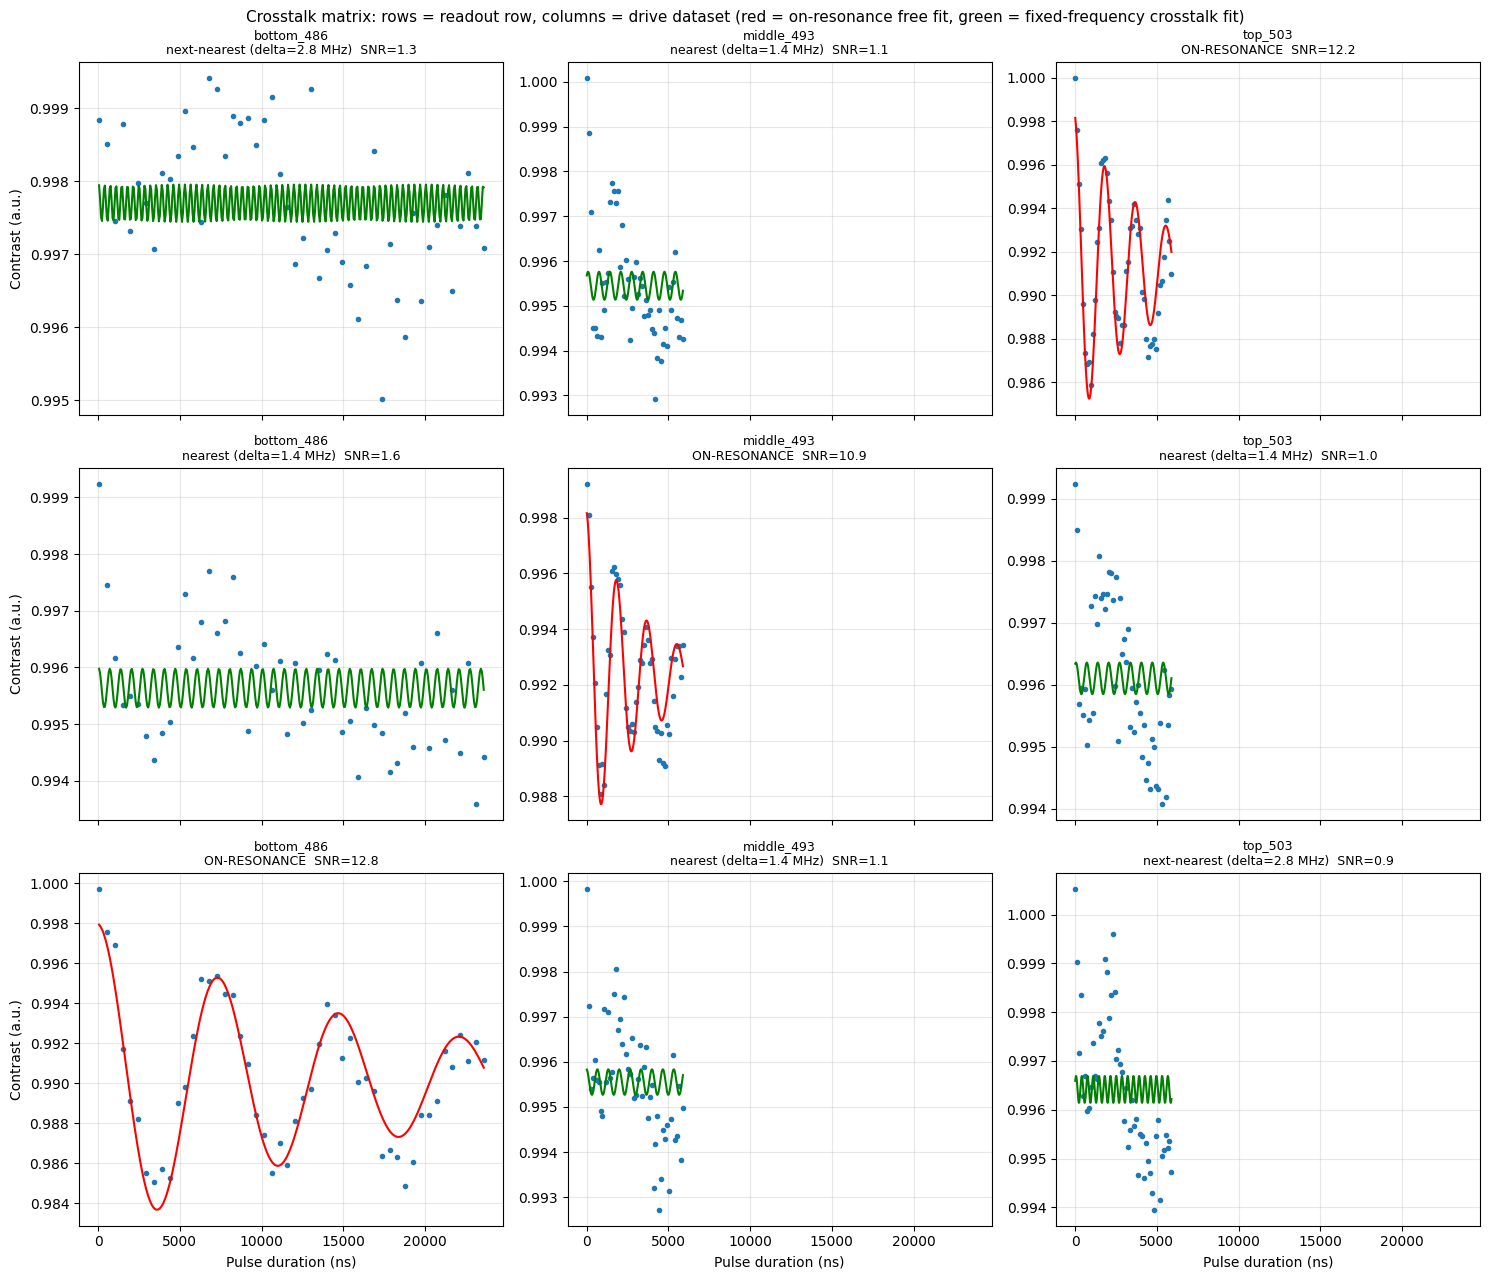

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13), sharex=True)

for col, label in enumerate(DATASETS):
    row_traces = row_traces_by_ds[label]
    addressed_i = addressed_by_ds[label]
    t_vec = loaded[label]['t_vec']
    t_fine = np.linspace(t_vec.min(), t_vec.max(), 400)

    for row_i in range(3):
        ax = axes[row_i, col]
        y = row_traces[row_i]
        ax.plot(t_vec, y, 'o', ms=3, color='C0')

        r = next(r for r in summary_rows if r['dataset'] == label and r['row_index'] == row_i)
        if row_i == addressed_i:
            popt, _ = fit_free(t_vec, y)
            ax.plot(t_fine, damped_cosine(t_fine, *popt), 'r-', lw=1.5)
            title = f'{label}\nON-RESONANCE  SNR={r["snr"]:.1f}'
        else:
            omega_eff_mhz = np.sqrt(omega_shared_mhz ** 2 + r['delta_mhz'] ** 2)
            amp, amp_unc, offset = fit_fixed_freq(t_vec, y, omega_eff_mhz * 1e-3)
            w = 2 * np.pi * omega_eff_mhz * 1e-3
            A = np.column_stack([np.ones_like(t_fine), np.cos(w * t_fine), np.sin(w * t_fine)])
            coeffs = [offset, amp, 0]  # phase absorbed; just show magnitude envelope via amp fit below
            # recompute a/b exactly for plotting
            Afit = np.column_stack([np.ones_like(t_vec), np.cos(w * t_vec), np.sin(w * t_vec)])
            c, *_ = np.linalg.lstsq(Afit, y, rcond=None)
            y_fit = A @ c
            ax.plot(t_fine, y_fit, 'g-', lw=1.5)
            title = f'{label}\n{r["kind"]} (delta={r["delta_mhz"]:.1f} MHz)  SNR={r["snr"]:.1f}'
        ax.set_title(title, fontsize=9)
        ax.grid(True, alpha=0.3)
        if row_i == 2:
            ax.set_xlabel('Pulse duration (ns)')
        if col == 0:
            ax.set_ylabel('Contrast (a.u.)')

fig.suptitle('Crosstalk matrix: rows = readout row, columns = drive dataset '
             '(red = on-resonance free fit, green = fixed-frequency crosstalk fit)',
             fontsize=11)
fig.tight_layout()
fig.savefig('crosstalk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SNR summary bar chart

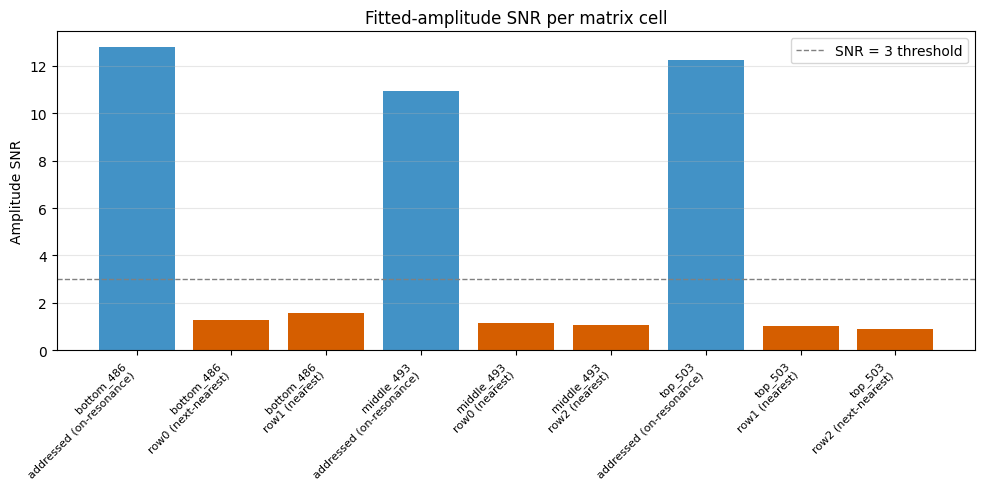

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = ['{}\n{} ({})'.format(r['dataset'], r['cell'], r['kind']) for r in summary_rows]
snrs = [r['snr'] for r in summary_rows]
colors = ['#4292c6' if s >= SNR_THRESHOLD else '#D55E00' for s in snrs]
ax.bar(range(len(snrs)), snrs, color=colors)
ax.axhline(SNR_THRESHOLD, color='gray', ls='--', lw=1, label=f'SNR = {SNR_THRESHOLD:.0f} threshold')
ax.set_xticks(range(len(snrs)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Amplitude SNR')
ax.set_title('Fitted-amplitude SNR per matrix cell')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig('crosstalk_snr_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusion

Run this notebook top-to-bottom against the current data to get an
up-to-date verdict per cell. As of the data available when this notebook was
authored:

- The on-resonance (diagonal) amplitude is well constrained in all three
  datasets (SNR well above threshold).
- **Every off-diagonal (crosstalk) cell — both nearest- and
  next-nearest-neighbor, across all three datasets — has amplitude SNR
  below the 3σ threshold** (roughly 1–1.6σ with the current statistics),
  even after combining all 3 columns of the 3x3 grid and using the more
  robust fixed-frequency matched-filter fit. **More averaging is needed
  before the off-diagonal amplitudes can be trusted as point estimates.**
- The `n_needed` column estimates the averaging factor required to reach
  SNR=3 assuming `SNR ∝ sqrt(N)`: roughly 4–12x more effective statistics
  (i.e., ~4–12x more tracking iterations, if collecting more of the same
  low-power data) depending on the cell.
- `bottom_486`'s own addressed-row frequency fit is poorly constrained
  (short/fast decay leaves less than one clean oscillation cycle resolved) —
  its Ω_eff calculations above intentionally use the shared/cross-calibrated
  Ω rather than its own fit. This dataset would also benefit from more
  averaging on its addressed row, independent of the crosstalk question.
- Given the averaging factor needed, also worth revisiting the power-sweep
  approach from `experimental_plan.md` (item 5) — raising Ω moves the
  crosstalk amplitude further from the noise floor directly, rather than
  purely through more averaging at the current low power.